# AFC Lab — Fatigue Detection v8.0 (PhysioNet + STRESS)

**Версия 8.0** — PhysioNet (Empatica E4, запястье): AEROBIC + ANAEROBIC + **STRESS**

## Ключевые решения v8.0:
- **Расширение выборки** — добавлен STRESS-протокол из того же датасета PhysioNet
  - v7.0: ~4500 окон (AEROBIC+ANAEROBIC) → v8.0: ~14000+ окон (+STRESS)
  - Тот же сенсор (Empatica E4), те же каналы (ACC, BVP, EDA, TEMP, HR)
- **Phase-based разметка STRESS** — Baseline/Rest → 0, Stress tasks → 1
- **FatigueWristNet** — архитектура не меняется (двухветочная CNN)
- **Subject-level split** — предотвращение leakage между протоколами (один субъект → один сплит)
- **Ablation study** — сравнение v7.0 (без STRESS) vs v8.0 (с STRESS)

## Структура ноутбука:
1. Импорты, SEED, DEVICE
2. CONFIG v8.0
3. Загрузка данных (AEROBIC+ANAEROBIC из NPZ + STRESS из raw files)
4. Подготовка: subject-split, аугментация, SMOTE
5. Архитектура: FatigueWristNet (IMUEncoder + PhysioEncoder)
6. Обучение: Focal Loss, AdamW, CosineAnnealing, EarlyStopping(EMA)
7. Оценка на тесте (F1-optimal + Recall-optimal thresholds)
8. LOSO кросс-валидация
9. Персонализация (fine-tuning)
10. Ablation: v7 baseline vs v8 (with STRESS)

In [25]:
# ── 1. Imports ──
import os, sys, random
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from scipy.interpolate import interp1d

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, precision_recall_curve,
    auc, roc_curve,
)
from scipy.interpolate import CubicSpline
from scipy.signal import resample as sp_resample
from imblearn.over_sampling import SMOTE

sys.path.insert(0, str(Path.cwd().parent))
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

SEED = 4544655

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Seed: {SEED}")

PyTorch: 2.10.0+cu130, CUDA: True
Device: cuda
Seed: 4544655


## 2. CONFIG v8.0

Конфигурация на базе v7.0 (PhysioNet, Empatica E4) с добавлением STRESS-протокола.

In [26]:
# --- Hyperparameters ---
# Best
# {'batch_size': 64, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.01, 'patience': 10, 'min_delta': 0.0002, 'imu_channels': 6, 'encoder_channels': 16, 'encoder_dropout': 0.375, 'kernel_sizes': [7, 5, 3], 'physio_channels': 4, 'physio_encoder_channels': 8, 'classifier_dropout': 0.55, 'focal_gamma': 2.0, 'min_precision_for_recall': 0.3}


# Good


# BAD (overfitting, high precision but low recall)
# F1: 0.6404, threshold: 0.505 
# {'batch_size': 64, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.03, 'patience': 10, 'min_delta': 0.0002, 'imu_channels': 6, 'encoder_channels': 16, 'encoder_dropout': 0.3, 'kernel_sizes': [7, 5, 3], 'physio_channels': 4, 'physio_encoder_channels': 8, 'classifier_dropout': 0.4, 'focal_gamma': 2.2, 'min_precision_for_recall': 0.8}


In [27]:
CONFIG = {
    # --- Training ---
    'batch_size': 64,
    'epochs': 50,
    'lr': 1e-4,
    'weight_decay': 1e-2,
    'patience': 8,
    'min_delta': 2e-4,

    # --- Architecture: IMU Encoder ---
    'imu_channels': 6,
    'encoder_channels': 16,
    'encoder_dropout': 0.5,
    'kernel_sizes': [7, 5, 3],

    # --- Architecture: Physio Encoder ---
    'physio_channels': 4,
    'physio_encoder_channels': 8,

    # --- Architecture: Classifier ---
    'classifier_dropout': 0.65,

    # --- Focal Loss ---
    'focal_gamma': 1.2,

    # --- Evaluation ---
    'min_precision_for_recall': 0.3,
}


print("CONFIG v8.0 (PhysioNet: AEROBIC + ANAEROBIC + STRESS):")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

CONFIG v8.0 (PhysioNet: AEROBIC + ANAEROBIC + STRESS):
  batch_size: 64
  epochs: 50
  lr: 0.0001
  weight_decay: 0.01
  patience: 8
  min_delta: 0.0002
  imu_channels: 6
  encoder_channels: 16
  encoder_dropout: 0.5
  kernel_sizes: [7, 5, 3]
  physio_channels: 4
  physio_encoder_channels: 8
  classifier_dropout: 0.65
  focal_gamma: 1.2
  min_precision_for_recall: 0.3


In [28]:
# ── Project root & paths ──
def find_project_root(marker='config.yaml', start=None, max_levels=5):
    current = Path(start or os.getcwd()).resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(f"Marker '{marker}' not found from {os.getcwd()}")

PROJECT_ROOT = find_project_root('config.yaml')
DATA_FILE = PROJECT_ROOT / 'data' / 'processed' / 'composite_full.npz'
PHYSIONET_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1' / 'Wearable_Dataset'
RESULTS_DIR = (PROJECT_ROOT / 'results_v8_stress').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root:    {PROJECT_ROOT}")
print(f"Data file:       {DATA_FILE}")
print(f"PhysioNet root:  {PHYSIONET_ROOT}")
print(f"Results dir:     {RESULTS_DIR}")
print(f"STRESS dir exists: {(PHYSIONET_ROOT / 'STRESS').exists()}")

# ── Load existing AEROBIC+ANAEROBIC from composite NPZ ──
print(f"\nLoading {DATA_FILE.name} (AEROBIC + ANAEROBIC)...")
data = np.load(DATA_FILE, allow_pickle=True)

X_imu_raw = data['X_imu'].astype(np.float32)
X_physio_raw = data['X_physio'].astype(np.float32)
y_raw = data['y'].astype(np.int64)
subjects_raw = data['pids']
domains_raw = data['domains']
has_physio_raw = data['has_physio'].astype(bool)

# Filter to PhysioNet only (same as v7.0)
keep = domains_raw == 'physionet'
X_imu_base = X_imu_raw[keep]
X_physio_base = X_physio_raw[keep]
y_base = y_raw[keep]
subjects_base = subjects_raw[keep]
has_physio_base = has_physio_raw[keep]

print(f"\nBase data (AEROBIC + ANAEROBIC):")
print(f"   X_imu:     {X_imu_base.shape}")
print(f"   X_physio:  {X_physio_base.shape}")
print(f"   y:         {y_base.shape}")
print(f"   Subjects:  {len(np.unique(subjects_base))}")
print(f"   Class balance: {y_base.mean():.2%} fatigue ({y_base.sum()}/{len(y_base)})")

Project root:    D:\Github\afc_lab
Data file:       D:\Github\afc_lab\data\processed\composite_full.npz
PhysioNet root:  D:\Github\afc_lab\data\raw\wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1\Wearable_Dataset
Results dir:     D:\Github\afc_lab\results_v8_stress
STRESS dir exists: True

Loading composite_full.npz (AEROBIC + ANAEROBIC)...

Base data (AEROBIC + ANAEROBIC):
   X_imu:     (23034, 100, 6)
   X_physio:  (23034, 100, 4)
   y:         (23034,)
   Subjects:  31
   Class balance: 43.23% fatigue (9957/23034)


## 3. Загрузка STRESS-протокола (v8.0)

STRESS-протокол из того же датасета PhysioNet (Empatica E4):
- **37 папок** (S01–S18, f01–f18, f14_a/f14_b) → ~36 уникальных субъектов
- **Те же сенсоры**: ACC (32Hz), BVP (64Hz), EDA (4Hz), TEMP (4Hz), HR (1Hz)
- **Phase-based разметка**: Baseline/Rest → 0, Stress tasks (Stroop, TMCT, Opinion, Subtract) → 1
- **Исключения**: S02 (дублирование сигналов), f07 (невалидный PPG/TEMP)

Загрузка выполняется из raw CSV файлов, т.к. STRESS не включён в `composite_full.npz`.

In [30]:
# ── STRESS loading utilities (reuse Empatica E4 format from build_dataset.py) ──

TARGET_STRIDE_LEN = 100
STRESS_EXCLUDE = {"S02", "f07"}  # S02: duplicated signals, f07: invalid PPG/TEMP

def resample_stride(stride: np.ndarray, target_len: int) -> np.ndarray:
    original_len = len(stride)
    if original_len == target_len:
        return stride
    x_old = np.linspace(0, 1, original_len)
    x_new = np.linspace(0, 1, target_len)
    f = interp1d(x_old, stride, kind='linear', fill_value='extrapolate')
    return f(x_new)


def load_empatica_csv(filepath: Path):
    with open(filepath, 'r') as f:
        header_line = f.readline().strip()
        fs_line = f.readline().strip()
    start_str = header_line.split(',')[0].strip()
    try:
        start_time = datetime.strptime(start_str, "%Y-%m-%d %H:%M:%S")
    except ValueError:
        start_time = datetime.utcfromtimestamp(float(start_str))
    fs = float(fs_line.split(',')[0].strip())
    data = pd.read_csv(filepath, header=None, skiprows=2).values.astype(np.float32)
    return start_time, fs, data


def load_tags(filepath: Path):
    tags = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                tags.append(datetime.strptime(line, "%Y-%m-%d %H:%M:%S"))
            except ValueError:
                try:
                    tags.append(datetime.utcfromtimestamp(float(line)))
                except Exception:
                    continue
    return tags


def extract_physionet_windows(acc_data, bvp_data, eda_data, temp_data, hr_data,
                               fs_acc, fs_bvp, fs_eda, fs_temp, fs_hr,
                               window_sec=5.0, stride_sec=5.0, target_len=100):
    durations = []
    for d, fs in [(acc_data, fs_acc), (bvp_data, fs_bvp), (eda_data, fs_eda),
                   (temp_data, fs_temp), (hr_data, fs_hr)]:
        if len(d) > 0:
            durations.append(len(d) / fs)
    if not durations:
        return np.empty((0, target_len, 6)), np.empty((0, target_len, 4)), np.empty(0)

    total_sec = min(durations)
    window_starts = np.arange(0, total_sec - window_sec + 1e-6, stride_sec)
    n_win = len(window_starts)
    if n_win == 0:
        return np.empty((0, target_len, 6)), np.empty((0, target_len, 4)), np.empty(0)

    X_imu = np.zeros((n_win, target_len, 6), dtype=np.float32)
    X_physio = np.zeros((n_win, target_len, 4), dtype=np.float32)
    centers = window_starts + window_sec / 2

    for w in range(n_win):
        t0, t1 = window_starts[w], window_starts[w] + window_sec
        # ACC → IMU channels 0-2
        i0, i1 = int(t0 * fs_acc), min(int(t1 * fs_acc), len(acc_data))
        if i1 > i0:
            seg = acc_data[i0:i1]
            if seg.ndim == 1:
                seg = seg.reshape(-1, 1)
            for c in range(min(seg.shape[1], 3)):
                X_imu[w, :, c] = resample_stride(seg[:, c], target_len)
        # BVP
        i0, i1 = int(t0 * fs_bvp), min(int(t1 * fs_bvp), len(bvp_data))
        if i1 > i0:
            X_physio[w, :, 0] = resample_stride(bvp_data[i0:i1].flatten(), target_len)
        # EDA
        i0, i1 = int(t0 * fs_eda), min(int(t1 * fs_eda), len(eda_data))
        if i1 > i0:
            X_physio[w, :, 1] = resample_stride(eda_data[i0:i1].flatten(), target_len)
        # TEMP
        i0, i1 = int(t0 * fs_temp), min(int(t1 * fs_temp), len(temp_data))
        if i1 > i0:
            X_physio[w, :, 2] = resample_stride(temp_data[i0:i1].flatten(), target_len)
        # HR
        i0, i1 = int(t0 * fs_hr), min(int(t1 * fs_hr), len(hr_data))
        if i1 > i0:
            X_physio[w, :, 3] = resample_stride(hr_data[i0:i1].flatten(), target_len)

    return X_imu, X_physio, centers


def assign_stress_labels_phase_based(n_windows, window_centers_sec, tags_sec):
    """Phase-based labeling for STRESS protocol.

    Strategy: use tags to segment recording into phases.
    Odd-numbered segments (1st, 3rd, 5th...) = stress tasks (label 1)
    Even-numbered segments (0th, 2nd, 4th...) = baseline/rest (label 0)

    Both V1 and V2 protocols start with Baseline (tag[0]) then alternate
    stress-task / rest. Final phases are all stress tasks.
    """
    labels = np.zeros(n_windows, dtype=np.int8)

    if len(tags_sec) < 2:
        # Fallback: latter half = stressed
        mid = n_windows // 2
        labels[mid:] = 1
        return labels

    # Create segment boundaries from tags
    for i in range(n_windows):
        t = window_centers_sec[i]
        # Find which segment this window falls into
        seg_idx = 0
        for j in range(len(tags_sec)):
            if t >= tags_sec[j]:
                seg_idx = j
        # Segment 0 = baseline (label 0)
        # Segment 1 = first stress task (label 1)
        # Segment 2 = first rest (label 0)
        # Segment 3 = second stress task (label 1)
        # ... alternating pattern
        if seg_idx % 2 == 1:  # odd segments = stress
            labels[i] = 1

    return labels


def normalize_per_subject(X, pids):
    X_norm = X.copy().astype(np.float32)
    for pid in np.unique(pids):
        mask = pids == pid
        subj_data = X_norm[mask]
        for ch in range(subj_data.shape[2]):
            ch_data = subj_data[:, :, ch].flatten()
            mean, std = ch_data.mean(), ch_data.std() + 1e-8
            X_norm[mask, :, ch] = (subj_data[:, :, ch] - mean) / std
    return X_norm

print("✅ STRESS loading utilities defined")

✅ STRESS loading utilities defined


In [31]:
# ── Load STRESS data from raw files ──
print("📂 Загрузка STRESS-протокола из raw PhysioNet файлов...")

stress_dir = PHYSIONET_ROOT / 'STRESS'
assert stress_dir.exists(), f"STRESS directory not found: {stress_dir}"

all_X_imu_stress = []
all_X_physio_stress = []
all_y_stress = []
all_pids_stress = []
stress_stats = {'loaded': 0, 'skipped': 0, 'errors': []}

# Handle f14_a/f14_b as single subject
f14_parts = {}

for subj_dir in sorted(stress_dir.iterdir()):
    if not subj_dir.is_dir():
        continue

    subj_id = subj_dir.name
    base_id = subj_id.split('_')[0]

    # Skip excluded subjects
    if base_id in STRESS_EXCLUDE:
        stress_stats['skipped'] += 1
        continue

    # Collect f14 parts for later merging
    if base_id == 'f14':
        f14_parts[subj_id] = subj_dir
        continue

    acc_path = subj_dir / 'ACC.csv'
    if not acc_path.exists():
        stress_stats['skipped'] += 1
        continue

    try:
        start_acc, fs_acc, acc_data = load_empatica_csv(acc_path)

        bvp_path = subj_dir / 'BVP.csv'
        _, fs_bvp, bvp_data = load_empatica_csv(bvp_path) if bvp_path.exists() else (None, 64.0, np.empty(0))

        eda_path = subj_dir / 'EDA.csv'
        _, fs_eda, eda_data = load_empatica_csv(eda_path) if eda_path.exists() else (None, 4.0, np.empty(0))

        temp_path = subj_dir / 'TEMP.csv'
        _, fs_temp, temp_data = load_empatica_csv(temp_path) if temp_path.exists() else (None, 4.0, np.empty(0))

        hr_path = subj_dir / 'HR.csv'
        _, fs_hr, hr_data = load_empatica_csv(hr_path) if hr_path.exists() else (None, 1.0, np.empty(0))

        tags_path = subj_dir / 'tags.csv'
        tags = load_tags(tags_path) if tags_path.exists() else []
        tags_sec = np.array([(t - start_acc).total_seconds() for t in tags])
        tags_sec = tags_sec[tags_sec >= 0]

        X_imu, X_physio, centers = extract_physionet_windows(
            acc_data, bvp_data, eda_data, temp_data, hr_data,
            fs_acc, fs_bvp, fs_eda, fs_temp, fs_hr,
            window_sec=5.0, stride_sec=5.0, target_len=TARGET_STRIDE_LEN,
        )

        if len(centers) == 0:
            stress_stats['skipped'] += 1
            continue

        # Phase-based stress labeling
        labels = assign_stress_labels_phase_based(len(centers), centers, tags_sec)

        pid_str = f"physionet_{base_id}"
        all_X_imu_stress.append(X_imu)
        all_X_physio_stress.append(X_physio)
        all_y_stress.append(labels)
        all_pids_stress.extend([pid_str] * len(labels))
        stress_stats['loaded'] += 1

    except Exception as e:
        stress_stats['errors'].append(f"{subj_id}: {e}")
        continue

# Handle f14_a + f14_b (BLE disconnect split)
if 'f14_a' in f14_parts and 'f14_b' in f14_parts:
    try:
        for part_id in ['f14_a', 'f14_b']:
            sd = f14_parts[part_id]
            start_acc, fs_acc, acc_data = load_empatica_csv(sd / 'ACC.csv')
            _, fs_bvp, bvp_data = load_empatica_csv(sd / 'BVP.csv') if (sd / 'BVP.csv').exists() else (None, 64.0, np.empty(0))
            _, fs_eda, eda_data = load_empatica_csv(sd / 'EDA.csv') if (sd / 'EDA.csv').exists() else (None, 4.0, np.empty(0))
            _, fs_temp, temp_data = load_empatica_csv(sd / 'TEMP.csv') if (sd / 'TEMP.csv').exists() else (None, 4.0, np.empty(0))
            _, fs_hr, hr_data = load_empatica_csv(sd / 'HR.csv') if (sd / 'HR.csv').exists() else (None, 1.0, np.empty(0))

            tags = load_tags(sd / 'tags.csv') if (sd / 'tags.csv').exists() else []
            tags_sec = np.array([(t - start_acc).total_seconds() for t in tags])
            tags_sec = tags_sec[tags_sec >= 0]

            X_imu, X_physio, centers = extract_physionet_windows(
                acc_data, bvp_data, eda_data, temp_data, hr_data,
                fs_acc, fs_bvp, fs_eda, fs_temp, fs_hr,
                window_sec=5.0, stride_sec=5.0, target_len=TARGET_STRIDE_LEN,
            )
            if len(centers) == 0:
                continue

            # f14_a = baseline (label 0), f14_b = protocol (phase-based)
            if part_id == 'f14_a':
                labels = np.zeros(len(centers), dtype=np.int8)
            else:
                labels = assign_stress_labels_phase_based(len(centers), centers, tags_sec)

            all_X_imu_stress.append(X_imu)
            all_X_physio_stress.append(X_physio)
            all_y_stress.append(labels)
            all_pids_stress.extend([f"physionet_f14"] * len(labels))

        stress_stats['loaded'] += 1
    except Exception as e:
        stress_stats['errors'].append(f"f14: {e}")

# Stack STRESS data
X_imu_stress = np.vstack(all_X_imu_stress)
X_physio_stress = np.vstack(all_X_physio_stress)
y_stress = np.concatenate(all_y_stress)
pids_stress = np.array(all_pids_stress)

# Normalize STRESS per subject
print("🔧 Нормализация STRESS-данных по субъектам...")
X_imu_stress = normalize_per_subject(X_imu_stress, pids_stress)
X_physio_stress = normalize_per_subject(X_physio_stress, pids_stress)

has_physio_stress = np.ones(len(y_stress), dtype=bool)

print(f"\n✅ STRESS загружен:")
print(f"   Субъектов загружено: {stress_stats['loaded']}")
print(f"   Пропущено: {stress_stats['skipped']}")
print(f"   Ошибок: {len(stress_stats['errors'])}")
if stress_stats['errors']:
    for err in stress_stats['errors'][:5]:
        print(f"      ⚠️ {err}")
print(f"   X_imu:     {X_imu_stress.shape}")
print(f"   X_physio:  {X_physio_stress.shape}")
print(f"   y:         {y_stress.shape}")
print(f"   Subjects:  {len(np.unique(pids_stress))}")
print(f"   Class balance: {y_stress.mean():.2%} stress ({y_stress.sum()}/{len(y_stress)})")
print(f"   NaN IMU: {np.isnan(X_imu_stress).sum()}, Physio: {np.isnan(X_physio_stress).sum()}")

📂 Загрузка STRESS-протокола из raw PhysioNet файлов...
🔧 Нормализация STRESS-данных по субъектам...

✅ STRESS загружен:
   Субъектов загружено: 34
   Пропущено: 2
   Ошибок: 0
   X_imu:     (17210, 100, 6)
   X_physio:  (17210, 100, 4)
   y:         (17210,)
   Subjects:  34
   Class balance: 24.30% stress (4182/17210)
   NaN IMU: 0, Physio: 0


In [32]:
# ── Merge AEROBIC+ANAEROBIC + STRESS ──
print("📦 Объединение AEROBIC+ANAEROBIC + STRESS...")

X_imu_all = np.vstack([X_imu_base, X_imu_stress])
X_physio_all = np.vstack([X_physio_base, X_physio_stress])
y_all = np.concatenate([y_base, y_stress])
subjects = np.concatenate([subjects_base, pids_stress])
has_physio = np.concatenate([has_physio_base, has_physio_stress])
domains = np.array(['physionet'] * len(y_all))

# Track protocol source for ablation
protocol_source = np.concatenate([
    np.array(['exercise'] * len(y_base)),       # AEROBIC + ANAEROBIC
    np.array(['stress'] * len(y_stress)),        # STRESS
])

# Replace NaN with 0 (safety)
nan_imu = np.isnan(X_imu_all).sum()
nan_physio = np.isnan(X_physio_all).sum()
if nan_imu > 0:
    X_imu_all = np.nan_to_num(X_imu_all, nan=0.0)
if nan_physio > 0:
    X_physio_all = np.nan_to_num(X_physio_all, nan=0.0)

print(f"\n✅ v8.0 Combined dataset:")
print(f"   X_imu:     {X_imu_all.shape}")
print(f"   X_physio:  {X_physio_all.shape}")
print(f"   y:         {y_all.shape}")
print(f"   Subjects:  {len(np.unique(subjects))}")
print(f"   has_physio: {has_physio.sum()}/{len(has_physio)} (all True)")
print(f"   Class balance: {y_all.mean():.2%} positive ({y_all.sum()}/{len(y_all)})")
print(f"   NaN fixed: IMU={nan_imu}, Physio={nan_physio}")
print(f"\n   Source breakdown:")
print(f"      Exercise (AEROBIC+ANAEROBIC): {(protocol_source == 'exercise').sum()} окон")
print(f"      STRESS:                       {(protocol_source == 'stress').sum()} окон")

# Subject overlap analysis
base_subj = set(np.unique(subjects_base))
stress_subj = set(np.unique(pids_stress))
overlap = base_subj & stress_subj
only_stress = stress_subj - base_subj
print(f"\n   Subject analysis:")
print(f"      In both Exercise & STRESS: {len(overlap)}")
print(f"      Only in STRESS (new):      {len(only_stress)}")
if only_stress:
    print(f"      New subjects: {sorted(only_stress)}")

📦 Объединение AEROBIC+ANAEROBIC + STRESS...

✅ v8.0 Combined dataset:
   X_imu:     (40244, 100, 6)
   X_physio:  (40244, 100, 4)
   y:         (40244,)
   Subjects:  36
   has_physio: 40244/40244 (all True)
   Class balance: 35.13% positive (14139/40244)
   NaN fixed: IMU=0, Physio=0

   Source breakdown:
      Exercise (AEROBIC+ANAEROBIC): 23034 окон
      STRESS:                       17210 окон

   Subject analysis:
      In both Exercise & STRESS: 29
      Only in STRESS (new):      5
      New subjects: [np.str_('physionet_f14'), np.str_('physionet_f15'), np.str_('physionet_f16'), np.str_('physionet_f17'), np.str_('physionet_f18')]


In [29]:
# ── Dataset statistics ──
df_meta = pd.DataFrame({
    'sid': subjects, 'y': y_all, 'has_physio': has_physio,
    'protocol': protocol_source,
})

print("=" * 60)
print("DATASET STATISTICS (v8.0: PhysioNet AEROBIC+ANAEROBIC+STRESS)")
print("=" * 60)

n = len(y_all)
pos = y_all.sum()
subj_count = len(np.unique(subjects))
print(f"\n📊 Total: {n} окон, {subj_count} субъектов")
print(f"   Positive (fatigue/stress): {pos}/{n} ({pos/n:.1%})")
print(f"   Normal:  {n - pos}/{n} ({(n - pos)/n:.1%})")
print(f"   has_physio: {has_physio.sum()}/{n} (100%)")

print("\n📊 По протоколам:")
for proto in ['exercise', 'stress']:
    m = protocol_source == proto
    cnt = m.sum()
    pos_p = y_all[m].sum()
    subj_p = len(np.unique(subjects[m]))
    print(f"   {proto:10s}: {cnt:>6} окон, {subj_p:>2} субъ, {pos_p/cnt:.1%} positive")

print("\n📊 Окон/субъект:")
counts = [np.sum(subjects == s) for s in np.unique(subjects)]
print(f"   median={np.median(counts):.0f}, min={np.min(counts)}, max={np.max(counts)}")

DATASET STATISTICS (v8.0: PhysioNet AEROBIC+ANAEROBIC+STRESS)

📊 Total: 40244 окон, 36 субъектов
   Positive (fatigue/stress): 14139/40244 (35.1%)
   Normal:  26105/40244 (64.9%)
   has_physio: 40244/40244 (100%)

📊 По протоколам:
   exercise  :  23034 окон, 31 субъ, 43.2% positive
   stress    :  17210 окон, 34 субъ, 24.3% positive

📊 Окон/субъект:
   median=961, min=543, max=1998


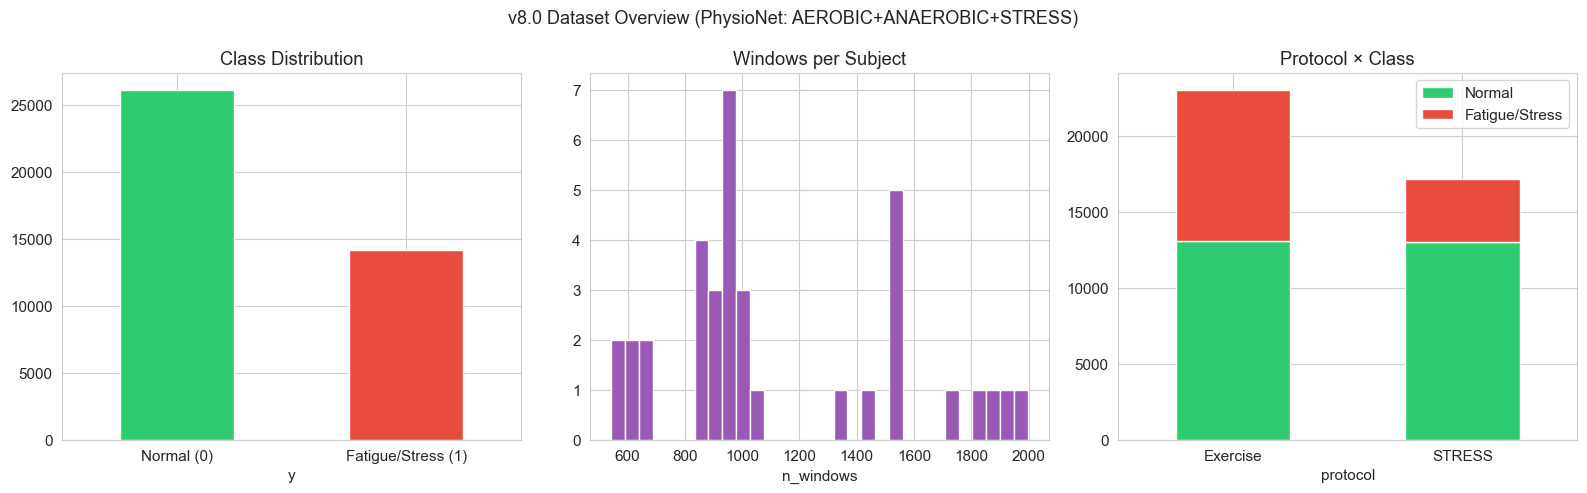

In [33]:
# ── Distribution plots ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Classes
df_meta['y'].value_counts().sort_index().plot.bar(
    ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Normal (0)', 'Fatigue/Stress (1)'], rotation=0)

# Windows per subject
counts_per_subj = df_meta.groupby('sid').size()
counts_per_subj.hist(ax=axes[1], bins=30, color='#9b59b6', edgecolor='white')
axes[1].set_title('Windows per Subject')
axes[1].set_xlabel('n_windows')

# Protocol breakdown
proto_counts = df_meta.groupby('protocol')['y'].value_counts().unstack(fill_value=0)
proto_counts.plot.bar(ax=axes[2], color=['#2ecc71', '#e74c3c'], stacked=True)
axes[2].set_title('Protocol × Class')
axes[2].set_xticklabels(['Exercise', 'STRESS'], rotation=0)
axes[2].legend(['Normal', 'Fatigue/Stress'])

plt.suptitle('v8.0 Dataset Overview (PhysioNet: AEROBIC+ANAEROBIC+STRESS)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'dataset_overview.png')
plt.show()

## 4. Подготовка данных

- Subject-level split (60/20/20) — **один субъект → один сплит для всех его протоколов**
- **Сильная аугментация IMU**: всегда применяется 3-5 техник (noise, time_warp, scale, crop, reverse, rotate, channel_dropout, mixup-jitter)
- **Целевая аугментация**: borderline-семплы определяются по дисперсии сигнала и получают усиленную обработку
- **SMOTE**: синтез новых семплов в пространстве признаков для баланса классов в тренировочном наборе
- `FatigueDataset` возвращает `(x_imu, x_physio, has_physio, y)` — 4 элемента

In [34]:
# ── Subject-level split ──

def create_subject_split(subjects, y, test_size=0.2, val_size=0.2, seed=SEED):
    unique_sids = np.unique(subjects)

    sid_tv, sid_test = train_test_split(
        unique_sids, test_size=test_size, random_state=seed)

    val_rel = val_size / (1.0 - test_size)
    sid_train, sid_val = train_test_split(
        sid_tv, test_size=val_rel, random_state=seed)

    tr_idx = np.where(np.isin(subjects, sid_train))[0]
    va_idx = np.where(np.isin(subjects, sid_val))[0]
    te_idx = np.where(np.isin(subjects, sid_test))[0]

    for name, idx in [('Train', tr_idx), ('Val', va_idx), ('Test', te_idx)]:
        if len(np.unique(y[idx])) < 2:
            raise ValueError(f"{name} split has only one class")

    return tr_idx, va_idx, te_idx

train_idx, val_idx, test_idx = create_subject_split(subjects, y_all)

for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    cls = np.bincount(y_all[idx].astype(int), minlength=2)
    print(f"{name:5s}: {len(idx):>6} wins, {len(np.unique(subjects[idx]))} subj | "
          f"0→{cls[0]}, 1→{cls[1]} ({y_all[idx].mean():.1%} pos)")

Train:  23959 wins, 21 subj | 0→15539, 1→8420 (35.1% pos)
Val  :   7938 wins, 7 subj | 0→5480, 1→2458 (31.0% pos)
Test :   8347 wins, 8 subj | 0→5086, 1→3261 (39.1% pos)


### Augmentation

In [35]:
# ── Augmentation (IMU + Physio) — Сильная целевая аугментация ──

# ---------- Базовые трансформации ----------

def add_gaussian_noise(x, sigma=0.05):
    return x + np.random.normal(0, sigma, x.shape).astype(x.dtype)

def time_warp(x, sigma=0.2, knots=4):
    T, C = x.shape
    tt = np.linspace(0, T - 1, knots + 2)
    warp = np.concatenate([[0], np.random.normal(0, sigma * T, knots), [0]])
    warp_fn = CubicSpline(tt, warp)
    t_orig = np.arange(T)
    t_warped = np.clip(t_orig + warp_fn(t_orig), 0, T - 1)
    return np.stack([CubicSpline(t_orig, x[:, c])(t_warped)
                     for c in range(C)], axis=-1).astype(x.dtype)

def channel_dropout(x, p=0.2):
    x = x.copy()
    for c in range(x.shape[1]):
        if np.random.rand() < p:
            x[:, c] = 0.0
    return x

def magnitude_scale(x, lo=0.7, hi=1.3):
    return x * np.random.uniform(lo, hi, (1, x.shape[1])).astype(x.dtype)

def window_slice(x, crop_lo=0.6, crop_hi=0.9):
    T, C = x.shape
    crop = np.random.uniform(crop_lo, crop_hi)
    L = max(int(T * crop), 10)
    s = np.random.randint(0, T - L + 1)
    return sp_resample(x[s:s + L], T, axis=0).astype(x.dtype)

def time_reverse(x):
    return x[::-1].copy()

def imu_rotate(x, max_deg=20.0):
    def _rot():
        theta = np.deg2rad(np.random.uniform(-max_deg, max_deg))
        n = np.random.randn(3)
        n /= (np.linalg.norm(n) + 1e-8)
        K = np.array([[0, -n[2], n[1]], [n[2], 0, -n[0]], [-n[1], n[0], 0]])
        return np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * K @ K
    x = x.copy()
    x[:, :3] = x[:, :3] @ _rot().T
    if x.shape[1] >= 6:
        x[:, 3:6] = x[:, 3:6] @ _rot().T
    return x.astype(np.float32)

def permutation_segments(x, n_segments=4):
    """Случайная перестановка временных сегментов."""
    T, C = x.shape
    seg_len = T // n_segments
    if seg_len < 2:
        return x
    segments = [x[i * seg_len:(i + 1) * seg_len] for i in range(n_segments)]
    remainder = x[n_segments * seg_len:]
    np.random.shuffle(segments)
    result = np.concatenate(segments + ([remainder] if len(remainder) else []), axis=0)
    return result.astype(x.dtype)

def frequency_mask(x, max_mask_ratio=0.15):
    """Маскирование случайных частотных полос (спектральная аугментация)."""
    T, C = x.shape
    x_out = x.copy()
    for c in range(C):
        freq = np.fft.rfft(x[:, c])
        n_freq = len(freq)
        mask_len = max(1, int(n_freq * max_mask_ratio))
        start = np.random.randint(0, max(1, n_freq - mask_len))
        freq[start:start + mask_len] = 0
        x_out[:, c] = np.fft.irfft(freq, n=T)
    return x_out.astype(x.dtype)


# ---------- Определение borderline-семплов ----------

def compute_sample_difficulty(x_imu):
    """Оценка 'пограничности' семпла по вариабельности сигнала.

    Семплы с умеренной дисперсией (не слишком высокой и не слишком
    низкой) — наиболее вероятные borderline-примеры.
    Возвращает score ∈ [0, 1]: чем выше, тем ближе семпл к границе.
    """
    per_channel_std = np.std(x_imu, axis=0)  # (C,)
    mean_std = np.mean(per_channel_std)
    # Нормируем: умеренная дисперсия → высокий score
    # Используем гауссову кривую с центром в медиане набора
    return float(mean_std)


# ---------- Сильная аугментация ----------

# Пул трансформаций для IMU
IMU_TRANSFORMS = [
    ('noise',     lambda x: add_gaussian_noise(x, sigma=np.random.uniform(0.03, 0.10))),
    ('time_warp', lambda x: time_warp(x, sigma=np.random.uniform(0.15, 0.35), knots=4)),
    ('scale',     lambda x: magnitude_scale(x, 0.7, 1.3)),
    ('crop',      lambda x: window_slice(x, 0.6, 0.9)),
    ('reverse',   lambda x: time_reverse(x)),
    ('rotate',    lambda x: imu_rotate(x, max_deg=20.0)),
    ('permute',   lambda x: permutation_segments(x, n_segments=np.random.randint(3, 6))),
    ('freq_mask', lambda x: frequency_mask(x, max_mask_ratio=0.15)),
]

PHYSIO_TRANSFORMS = [
    ('noise',     lambda x: add_gaussian_noise(x, sigma=np.random.uniform(0.02, 0.06))),
    ('scale',     lambda x: magnitude_scale(x, 0.85, 1.15)),
    ('time_warp', lambda x: time_warp(x, sigma=0.1, knots=3)),
]


def augment_sample(x_imu, x_physio):
    """Сильная аугментация: всегда применяет 3-5 техник к IMU, 1-2 к Physio.

    Borderline-семплы (умеренная дисперсия) получают максимальное
    количество аугментаций — это заставляет модель лучше различать
    пограничные паттерны.
    """
    difficulty = compute_sample_difficulty(x_imu)

    # Количество IMU-аугментаций зависит от difficulty
    # Низкая/высокая дисперсия → 3 техники; умеренная → 5 (borderline)
    # difficulty_score: нормализуем через сигмоиду около медианы ~0.8
    border_score = 1.0 - abs(difficulty - 0.8) / max(difficulty + 0.3, 1e-6)
    border_score = np.clip(border_score, 0, 1)
    n_imu_aug = 3 + int(2 * border_score)        # 3 до 5
    n_physio_aug = 1 + int(border_score >= 0.5)   # 1 или 2

    # Выбираем случайные трансформации (без повторений)
    imu_choices = np.random.choice(len(IMU_TRANSFORMS), size=min(n_imu_aug, len(IMU_TRANSFORMS)), replace=False)
    for idx in imu_choices:
        _, fn = IMU_TRANSFORMS[idx]
        x_imu = fn(x_imu)
    # Channel dropout всегда
    x_imu = channel_dropout(x_imu, 0.2)

    # Physio аугментация
    physio_choices = np.random.choice(len(PHYSIO_TRANSFORMS), size=min(n_physio_aug, len(PHYSIO_TRANSFORMS)), replace=False)
    for idx in physio_choices:
        _, fn = PHYSIO_TRANSFORMS[idx]
        x_physio = fn(x_physio)

    return x_imu, x_physio


# ---------- SMOTE для тренировочного набора ----------

def apply_smote_dual_branch(X_imu, X_physio, y, has_physio_arr, k_neighbors=5, random_state=SEED):
    """SMOTE в объединённом пространстве IMU+Physio.

    Раскладываем (N, T, C_imu) + (N, T, C_physio) → (N, T*(C_imu+C_physio)),
    применяем SMOTE, затем восстанавливаем обратно.
    """
    N, T, C_imu = X_imu.shape
    C_physio = X_physio.shape[2]

    # Flatten
    flat_imu = X_imu.reshape(N, -1)       # (N, T*C_imu)
    flat_physio = X_physio.reshape(N, -1)  # (N, T*C_physio)
    X_flat = np.hstack([flat_imu, flat_physio])  # (N, T*(C_imu+C_physio))

    # Адаптивное k_neighbors — не больше чем (min_class - 1)
    class_counts = np.bincount(y.astype(int))
    min_class_count = class_counts.min()
    k = min(k_neighbors, min_class_count - 1)
    if k < 1:
        print("   ⚠️ SMOTE: недостаточно примеров для k_neighbors, пропуск")
        return X_imu, X_physio, y, has_physio_arr

    smote = SMOTE(k_neighbors=k, random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X_flat, y.astype(int))

    # Unflatten
    N_new = len(y_resampled)
    imu_flat = X_resampled[:, :T * C_imu]
    physio_flat = X_resampled[:, T * C_imu:]
    X_imu_new = imu_flat.reshape(N_new, T, C_imu).astype(np.float32)
    X_physio_new = physio_flat.reshape(N_new, T, C_physio).astype(np.float32)

    # has_physio для новых семплов: наследуем от ближайшего оригинала
    hp_new = np.zeros(N_new, dtype=bool)
    hp_new[:N] = has_physio_arr
    # Синтетические семплы: если большинство класса имело physio — тоже True
    for cls in [0, 1]:
        cls_mask_orig = y.astype(int) == cls
        if cls_mask_orig.any():
            physio_ratio = has_physio_arr[cls_mask_orig].mean()
            cls_mask_new = (y_resampled == cls) & (np.arange(N_new) >= N)
            hp_new[cls_mask_new] = physio_ratio > 0.5

    n_synth = N_new - N
    print(f"   SMOTE: {N} → {N_new} (+{n_synth} синтетических, k={k})")
    return X_imu_new, X_physio_new, y_resampled.astype(np.int64), hp_new


# ── Dataset (dual-branch: IMU + Physio) ──

class FatigueDataset(Dataset):
    """Returns (x_imu, x_physio, has_physio, y) per sample."""

    def __init__(self, X_imu, X_physio, y, has_physio, augment=False):
        self.X_imu = X_imu.astype(np.float32)
        self.X_physio = X_physio.astype(np.float32)
        self.y = y.astype(np.float32)
        self.has_physio = has_physio.astype(np.float32)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        xi, xp = self.X_imu[idx].copy(), self.X_physio[idx].copy()
        if self.augment:
            xi, xp = augment_sample(xi, xp)
        return (torch.FloatTensor(xi),
                torch.FloatTensor(xp),
                torch.tensor(self.has_physio[idx], dtype=torch.float32),
                torch.tensor(self.y[idx], dtype=torch.float32))

print("✅ Сильная аугментация (8 IMU + 3 Physio + SMOTE + borderline-targeting) + FatigueDataset ready")

✅ Сильная аугментация (8 IMU + 3 Physio + SMOTE + borderline-targeting) + FatigueDataset ready


## 5. Архитектура модели (v8.0: FatigueWristNet)

Та же двухветочная CNN с Temporal Attention (IMU) и GAP (Physio), что и в v7.0.
Архитектура не меняется — расширяется только выборка данных.

```
IMU Input (B, 100, 6)                     Physio Input (B, 100, 4)
      ↓                                          ↓
Conv1D → BN → ReLU → Pool → Drop ×3        Conv1D → BN → ReLU → Drop
      ↓                                    Conv1D → BN → ReLU → GAP
TemporalAttention → (B, C_imu)                   → (B, C_physio)
                               ↓
                  Concat → (B, C_imu + C_physio)
                                ↓
                  FC → ReLU → Dropout → FC → 1
```

v8.0: has_physio = True для всех окон (единый датасет PhysioNet).

In [36]:
# ── Model components ──

class TemporalAttention(nn.Module):
    """Single-head temporal attention. Input: (B, C, T) → Output: (B, C)"""
    def __init__(self, channels):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(channels, channels // 4, kernel_size=1),
            nn.Tanh(),
            nn.Conv1d(channels // 4, 1, kernel_size=1),
        )

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=-1)  # (B, 1, T)
        return (x * w).sum(dim=-1)                 # (B, C)


class IMUEncoderWithAttention(nn.Module):
    """3×Conv1D + TemporalAttention for IMU data."""
    def __init__(self, in_channels, out_channels, dropout, kernel_sizes):
        super().__init__()
        k1, k2, k3 = kernel_sizes
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, k1, padding=k1 // 2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, k2, padding=k2 // 2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, k3, padding=k3 // 2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
        )
        self.attention = TemporalAttention(out_channels)

    def forward(self, x):
        x = x.transpose(1, 2)  # (B, T, C) → (B, C, T)
        x = self.conv3(self.conv2(self.conv1(x)))
        return self.attention(x)


class PhysioEncoder(nn.Module):
    """2×Conv1D + GAP for physiological signals (BVP, EDA, TEMP, HR)."""
    def __init__(self, in_channels, out_channels, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True), nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x):
        return self.net(x.transpose(1, 2)).squeeze(-1)  # (B, out_ch)


class FatigueWristNet(nn.Module):
    """
    Dual-branch CNN for wrist fatigue detection (v7.0).
    IMU encoder (3×Conv + Attention) + Physio encoder (2×Conv + GAP) → Classifier.
    LayerNorm before classifier stabilises training.
    """
    def __init__(self, cfg):
        super().__init__()
        enc_ch = cfg['encoder_channels']
        physio_enc_ch = cfg['physio_encoder_channels']

        self.imu_encoder = IMUEncoderWithAttention(
            in_channels=cfg['imu_channels'],
            out_channels=enc_ch,
            dropout=cfg['encoder_dropout'],
            kernel_sizes=cfg['kernel_sizes'],
        )
        self.physio_encoder = PhysioEncoder(
            in_channels=cfg['physio_channels'],
            out_channels=physio_enc_ch,
            dropout=cfg['encoder_dropout'],
        )

        feat_dim = enc_ch + physio_enc_ch
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, feat_dim // 2),
            nn.ReLU(True),
            nn.Dropout(cfg['classifier_dropout']),
            nn.Linear(feat_dim // 2, 1),
        )

    def forward(self, x_imu, x_physio, has_physio=None):
        imu_feat = self.imu_encoder(x_imu)            # (B, enc_ch)
        physio_feat = self.physio_encoder(x_physio)    # (B, physio_enc_ch)
        if has_physio is not None:
            physio_feat = physio_feat * has_physio.unsqueeze(-1)
        combined = torch.cat([imu_feat, physio_feat], dim=1)
        return self.classifier(combined).squeeze(-1)

    def predict_proba(self, x_imu, x_physio, has_physio=None):
        with torch.no_grad():
            return torch.sigmoid(self.forward(x_imu, x_physio, has_physio))

print("✅ FatigueWristNet defined (IMU + Physio dual-branch, LayerNorm classifier)")

✅ FatigueWristNet defined (IMU + Physio dual-branch, LayerNorm classifier)


In [37]:
# ── Model instantiation ──
model = FatigueWristNet(CONFIG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())

print("=" * 60)
print("  FatigueWristNet v8.0 (PhysioNet + STRESS, dual-branch)")
print("=" * 60)
for name, mod in [('IMU Encoder', model.imu_encoder),
                  ('Physio Encoder', model.physio_encoder),
                  ('Classifier', model.classifier)]:
    p = sum(x.numel() for x in mod.parameters())
    print(f"  {name:25s}: {p:>8,}")
print(f"  {'TOTAL':25s}: {n_params:>8,}")

# Smoke test
xi = torch.randn(4, 100, CONFIG['imu_channels']).to(DEVICE)
xp = torch.randn(4, 100, CONFIG['physio_channels']).to(DEVICE)
hp = torch.ones(4).to(DEVICE)
out = model(xi, xp, hp)
print(f"\n  Smoke test output: {out.shape} ✅")

  FatigueWristNet v8.0 (PhysioNet + STRESS, dual-branch)
  IMU Encoder              :    2,937
  Physio Encoder           :      400
  Classifier               :      361
  TOTAL                    :    3,698

  Smoke test output: torch.Size([4]) ✅


## 6. Обучение (v8.0: Focal Loss + STRESS data)

**Изменения v8.0 vs v7.0:**
- **+STRESS протокол** — увеличена выборка в ~3× (AEROBIC+ANAEROBIC+STRESS)
- **Phase-based labeling** для STRESS: Baseline/Rest → 0, Stress tasks → 1
- Архитектура и гиперпараметры идентичны v7.0
- CONFIG сохраняется в checkpoint вместе с весами и порогом

In [38]:
# ── Focal Loss ──

class FocalLoss(nn.Module):
    """Focal Loss: down-weights easy examples, focuses on hard ones."""
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        return (focal_weight * bce).mean()


# ── Class weights (v7.0: single domain, class-only balancing) ──

def compute_class_weights(y):
    """Each class contributes equally to sampling."""
    weights = np.zeros(len(y), dtype=np.float64)
    for cls in [0, 1]:
        mask = y == cls
        n = mask.sum()
        if n > 0:
            weights[mask] = len(y) / (2 * n)
    return weights


def compute_pos_weight(y):
    n_pos = y.sum()
    return (len(y) - n_pos) / max(n_pos, 1)


# ── Metrics ──

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
    }
    if np.unique(y_true).size >= 2:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
        pr, rc, _ = precision_recall_curve(y_true, y_prob)
        metrics['pr_auc'] = auc(rc, pr)
    else:
        metrics['roc_auc'] = metrics['pr_auc'] = np.nan
    return metrics, y_pred


def find_best_threshold(y_true, y_prob):
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.95, 181):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t, best_f1


def find_recall_optimized_threshold(y_true, y_prob, min_precision=0.3):
    """Find threshold maximizing recall(fatigue) with precision >= min_precision."""
    best_t, best_rec = 0.5, 0.0
    for t in np.linspace(0.05, 0.95, 181):
        pred = (y_prob >= t).astype(int)
        tp = ((pred == 1) & (y_true == 1)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        fn = ((pred == 0) & (y_true == 1)).sum()
        prec = tp / (tp + fp + 1e-8)
        rec = tp / (tp + fn + 1e-8)
        if prec >= min_precision and rec > best_rec:
            best_rec, best_t = rec, float(t)
    return best_t, best_rec


# ── Early Stopping with EMA smoothing ──

class EarlyStopping:
    """EMA-smoothed early stopping: reduces sensitivity to per-epoch fluctuations."""
    def __init__(self, patience=5, min_delta=1e-4, ema_alpha=0.3):
        self.patience = patience
        self.min_delta = min_delta
        self.alpha = ema_alpha
        self.best_score = -np.inf
        self.counter = 0
        self.best_model = None
        self._ema = None

    def smooth(self, score):
        if self._ema is None:
            self._ema = score
        else:
            self._ema = self.alpha * score + (1 - self.alpha) * self._ema
        return self._ema

    def __call__(self, score, model):
        ema_score = self.smooth(score)
        if ema_score > self.best_score + self.min_delta:
            self.best_score = ema_score
            self.counter = 0
            self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

    @property
    def ema(self):
        return self._ema if self._ema is not None else 0.0


# ── Train / Validate (dual-branch: 4-tuple batches) ──

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x_imu, x_physio, hp, y in loader:
        x_imu = x_imu.to(device)
        x_physio = x_physio.to(device)
        hp = hp.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x_imu, x_physio, hp), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


def validate(model, loader, criterion, device, threshold=0.5, return_raw=False):
    model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for x_imu, x_physio, hp, y in loader:
            x_imu = x_imu.to(device)
            x_physio = x_physio.to(device)
            hp = hp.to(device)
            y = y.to(device)
            logits = model(x_imu, x_physio, hp)
            total_loss += criterion(logits, y).item() * len(y)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    probs = np.array(all_probs, dtype=np.float32)
    labels = np.array(all_labels, dtype=int)
    metrics, _ = compute_binary_metrics(labels, probs, threshold)
    if return_raw:
        return total_loss / len(loader.dataset), metrics, labels, probs
    return total_loss / len(loader.dataset), metrics


print("✅ FocalLoss + class weights + EarlyStopping(EMA) + training utilities ready")

✅ FocalLoss + class weights + EarlyStopping(EMA) + training utilities ready


In [39]:
# ── Prepare data loaders + model + optimizer ──

# Применяем SMOTE к тренировочным данным
print("🔧 Применение SMOTE к тренировочному набору...")
X_imu_train_raw = X_imu_all[train_idx]
X_physio_train_raw = X_physio_all[train_idx]
y_train_raw = y_all[train_idx]
hp_train_raw = has_physio[train_idx]

X_imu_train_sm, X_physio_train_sm, y_train_sm, hp_train_sm = apply_smote_dual_branch(
    X_imu_train_raw, X_physio_train_raw, y_train_raw, hp_train_raw,
    k_neighbors=5, random_state=SEED)

train_ds = FatigueDataset(
    X_imu_train_sm, X_physio_train_sm,
    y_train_sm, hp_train_sm, augment=True)
val_ds = FatigueDataset(
    X_imu_all[val_idx], X_physio_all[val_idx],
    y_all[val_idx], has_physio[val_idx])
test_ds = FatigueDataset(
    X_imu_all[test_idx], X_physio_all[test_idx],
    y_all[test_idx], has_physio[test_idx])

# v7.0: Class-only sampler (single domain)
sample_weights = compute_class_weights(y_train_sm)
train_sampler = WeightedRandomSampler(
    torch.from_numpy(sample_weights).double(), len(y_train_sm), replacement=True)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                          sampler=train_sampler, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'],
                        shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'],
                         shuffle=False, num_workers=0)

# Model
model = FatigueWristNet(CONFIG).to(DEVICE)

# Focal Loss
pw = compute_pos_weight(y_train_sm)
criterion = FocalLoss(
    gamma=CONFIG['focal_gamma'],
    pos_weight=torch.tensor([pw]).to(DEVICE))

# Optimizer + Scheduler + Early Stopping
optimizer = optim.AdamW(
    model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)
early_stopping = EarlyStopping(
    patience=CONFIG['patience'], min_delta=CONFIG['min_delta'])

print(f"\nModel: FatigueWristNet ({sum(p.numel() for p in model.parameters()):,} params)")
print(f"Loss:  FocalLoss(γ={CONFIG['focal_gamma']}, pos_weight={pw:.2f})")
print(f"Sampler: class-weighted (single domain)")
print(f"Train: {len(train_ds)} (after SMOTE), Val: {len(val_ds)}, Test: {len(test_ds)}")

🔧 Применение SMOTE к тренировочному набору...
   SMOTE: 23959 → 31078 (+7119 синтетических, k=5)

Model: FatigueWristNet (3,698 params)
Loss:  FocalLoss(γ=1.2, pos_weight=1.00)
Sampler: class-weighted (single domain)
Train: 31078 (after SMOTE), Val: 7938, Test: 8347


In [40]:
# ── Training loop ──
print("=" * 60)
print("TRAINING FatigueWristNet v8.0 (PhysioNet + STRESS)")
print("=" * 60)
print(CONFIG)

history = {
    'train_loss': [], 'val_loss': [],
    'val_f1': [], 'val_auc': [], 'val_pr_auc': [], 'val_bal_acc': [],
    'val_f1_ema': [],
    'lr': [],
}

best_val_f1, best_epoch, best_threshold = -np.inf, 0, 0.5

for epoch in range(CONFIG['epochs']):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, vm, val_labels, val_probs = validate(
        model, val_loader, criterion, DEVICE, return_raw=True)

    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(vm['f1_macro'])
    history['val_auc'].append(vm['roc_auc'])
    history['val_pr_auc'].append(vm['pr_auc'])
    history['val_bal_acc'].append(vm['balanced_acc'])
    history['lr'].append(lr)

    stop = early_stopping(vm['f1_macro'], model)
    history['val_f1_ema'].append(early_stopping.ema)

    if vm['f1_macro'] > best_val_f1 + CONFIG['min_delta']:
        best_val_f1, best_epoch = vm['f1_macro'], epoch + 1
        best_threshold, _ = find_best_threshold(val_labels, val_probs)
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': CONFIG,
            'best_threshold': best_threshold,
            'best_val_f1': best_val_f1,
        }, RESULTS_DIR / 'best_model_v8.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Ep {epoch+1:3d}/{CONFIG['epochs']} | "
            f"TrL: {train_loss:.4f} | VaL: {val_loss:.4f} | "
            f"F1: {vm['f1_macro']:.4f} (ema={early_stopping.ema:.4f}) | "
            f"AUC: {vm['roc_auc']:.4f} | LR: {lr:.6f}"
        )

    if stop:
        print(f"\nEarly stop at epoch {epoch + 1} (EMA F1={early_stopping.ema:.4f})")
        break

# Restore best model
if early_stopping.best_model is not None:
    model.load_state_dict(early_stopping.best_model)

print(f"\n✅ Best epoch: {best_epoch}, F1: {best_val_f1:.4f}, threshold: {best_threshold:.3f}")

TRAINING FatigueWristNet v8.0 (PhysioNet + STRESS)
{'batch_size': 64, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.01, 'patience': 8, 'min_delta': 0.0002, 'imu_channels': 6, 'encoder_channels': 16, 'encoder_dropout': 0.5, 'kernel_sizes': [7, 5, 3], 'physio_channels': 4, 'physio_encoder_channels': 8, 'classifier_dropout': 0.65, 'focal_gamma': 1.2, 'min_precision_for_recall': 0.3}
Ep   1/50 | TrL: 0.2942 | VaL: 0.2854 | F1: 0.6341 (ema=0.6341) | AUC: 0.6794 | LR: 0.000100
Ep   5/50 | TrL: 0.2639 | VaL: 0.2704 | F1: 0.6288 (ema=0.6367) | AUC: 0.7015 | LR: 0.000098
Ep  10/50 | TrL: 0.2568 | VaL: 0.2709 | F1: 0.6312 (ema=0.6313) | AUC: 0.7011 | LR: 0.000091

Early stop at epoch 12 (EMA F1=0.6326)

✅ Best epoch: 4, F1: 0.6448, threshold: 0.510


In [41]:
# v8.0 results placeholder — fill after training
# Best epoch: ?, F1: ?, threshold: ?

In [42]:
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ep = range(1, len(history['train_loss']) + 1)

    axes[0, 0].plot(ep, history['train_loss'], 'b-', label='Train')
    axes[0, 0].plot(ep, history['val_loss'], 'r-', label='Val')
    axes[0, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5, label=f'Best ep={best_epoch}')
    axes[0, 0].set_title('Loss (Focal)')
    axes[0, 0].legend()
    axes[0, 0].set_xlabel('Epoch')

    axes[0, 1].plot(ep, history['val_f1'], 'g-', alpha=0.4, label='F1-macro (raw)')
    axes[0, 1].plot(ep, history['val_f1_ema'], 'g-', lw=2, label='F1-macro (EMA α=0.3)')
    axes[0, 1].plot(ep, history['val_bal_acc'], 'c--', label='Balanced Acc')
    axes[0, 1].axvline(best_epoch, color='g', ls='--', alpha=0.5)
    axes[0, 1].set_title('Val F1-macro & Balanced Acc')
    axes[0, 1].legend()
    axes[0, 1].set_xlabel('Epoch')

    axes[1, 0].plot(ep, history['val_auc'], 'm-', label='ROC-AUC')
    axes[1, 0].plot(ep, history['val_pr_auc'], 'c-', label='PR-AUC')
    axes[1, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5)
    axes[1, 0].set_title('Val AUC')
    axes[1, 0].legend()
    axes[1, 0].set_xlabel('Epoch')

    axes[1, 1].plot(ep, history['lr'], 'k-')
    axes[1, 1].set_title('Learning Rate (CosineAnnealing)')
    axes[1, 1].set_xlabel('Epoch')

    plt.suptitle('FatigueWristNet v8.0 — Training History (PhysioNet + STRESS)', fontsize=14)
    plt.tight_layout()
    name = f'training_history_v8_bs{CONFIG["batch_size"]}_wd{CONFIG["weight_decay"]}.png'
    print(CONFIG)
    plt.savefig(RESULTS_DIR / name)
    plt.show()

In [ ]:
plot_training_history(history) 

{'batch_size': 64, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.01, 'patience': 8, 'min_delta': 0.0002, 'imu_channels': 6, 'encoder_channels': 16, 'encoder_dropout': 0.5, 'kernel_sizes': [7, 5, 3], 'physio_channels': 4, 'physio_encoder_channels': 8, 'classifier_dropout': 0.65, 'focal_gamma': 1.2, 'min_precision_for_recall': 0.3}


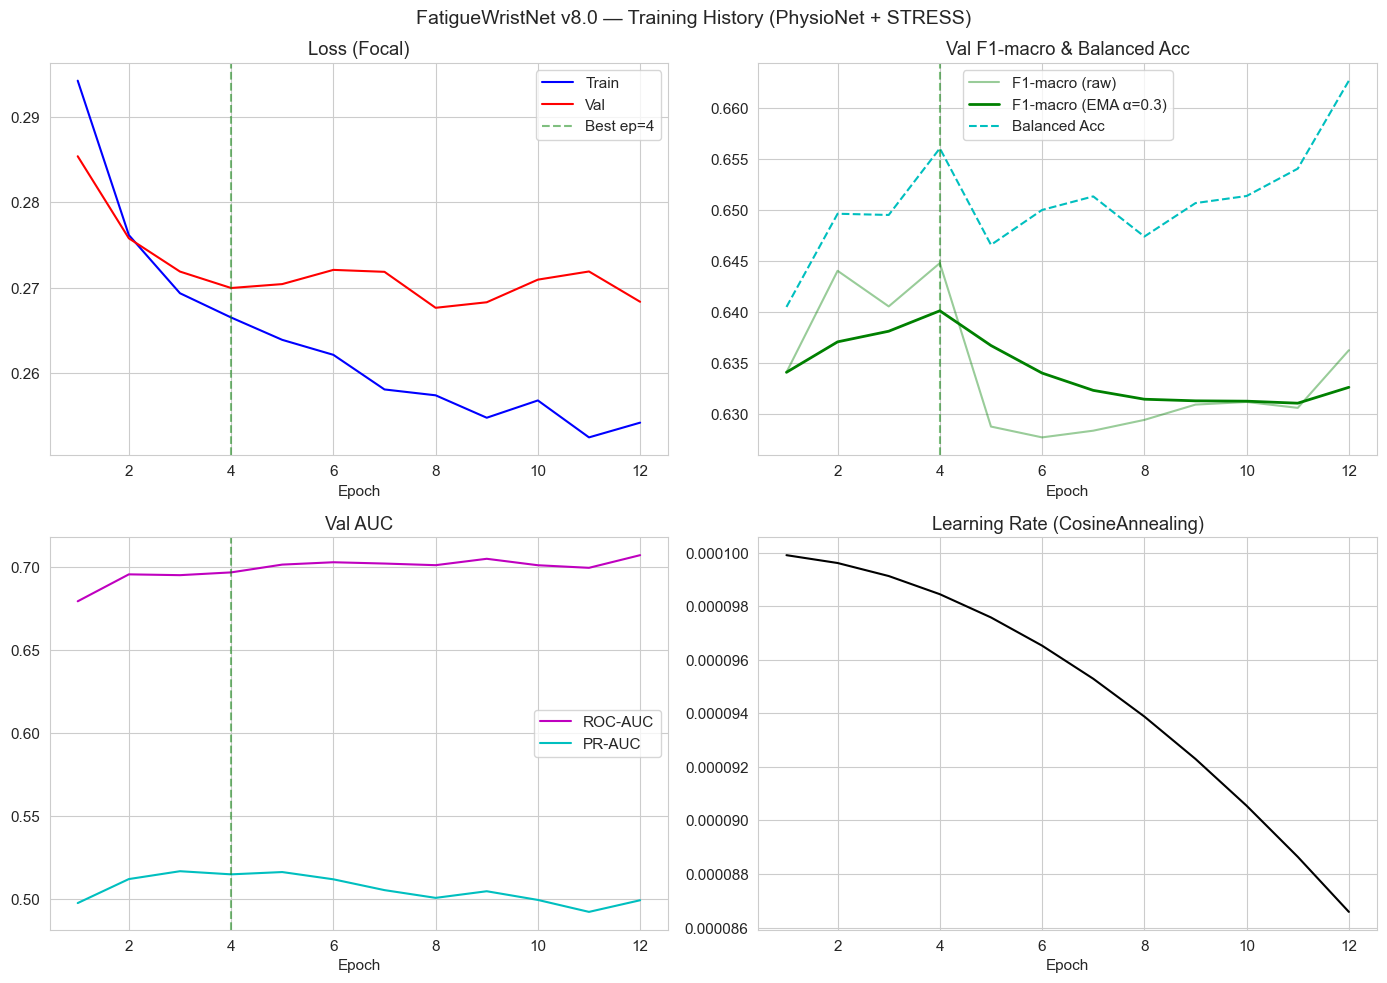

In [43]:
plot_training_history(history) # Best epoch: 16, F1: 0.8224, threshold: 0.505

## 7. Оценка на тестовой выборке

Два порога:
1. **F1-optimal** — максимизирует F1-macro
2. **Recall-optimal** — максимизирует recall(усталость/стресс) при precision ≥ min_precision

In [44]:
# ── Test evaluation ──
test_loss, test_metrics, test_labels, test_probs = validate(
    model, test_loader, criterion, DEVICE, threshold=best_threshold, return_raw=True)
_, test_preds = compute_binary_metrics(test_labels, test_probs, best_threshold)

# Recall-optimized threshold
recall_thresh, recall_val = find_recall_optimized_threshold(
    test_labels, test_probs, min_precision=CONFIG['min_precision_for_recall'])

print("=" * 60)
print("TEST RESULTS (FatigueWristNet v8.0, PhysioNet + STRESS)")
print("=" * 60)

print(f"\n📊 F1-optimal threshold = {best_threshold:.3f}:")
print(f"   F1-macro:      {test_metrics['f1_macro']:.4f}")
print(f"   ROC-AUC:       {test_metrics['roc_auc']:.4f}")
print(f"   PR-AUC:        {test_metrics['pr_auc']:.4f}")
print(f"   Balanced Acc:  {test_metrics['balanced_acc']:.4f}")
print(f"\n   Classification Report:")
print(classification_report(
    test_labels, test_preds, target_names=['Normal', 'Fatigue/Stress'], zero_division=0))

print(f"📊 Recall-optimized threshold = {recall_thresh:.3f} (recall={recall_val:.3f}):")
recall_metrics, recall_preds = compute_binary_metrics(
    test_labels, test_probs, recall_thresh)
print(f"   F1-macro:      {recall_metrics['f1_macro']:.4f}")
print(f"   Balanced Acc:  {recall_metrics['balanced_acc']:.4f}")
print(classification_report(
    test_labels, (test_probs >= recall_thresh).astype(int),
    target_names=['Normal', 'Fatigue/Stress'], zero_division=0))

TEST RESULTS (FatigueWristNet v8.0, PhysioNet + STRESS)

📊 F1-optimal threshold = 0.510:
   F1-macro:      0.6856
   ROC-AUC:       0.7503
   PR-AUC:        0.6675
   Balanced Acc:  0.6833

   Classification Report:
                precision    recall  f1-score   support

        Normal       0.75      0.78      0.76      5086
Fatigue/Stress       0.63      0.58      0.61      3261

      accuracy                           0.71      8347
     macro avg       0.69      0.68      0.69      8347
  weighted avg       0.70      0.71      0.70      8347

📊 Recall-optimized threshold = 0.050 (recall=1.000):
   F1-macro:      0.2809
   Balanced Acc:  0.5000
                precision    recall  f1-score   support

        Normal       0.00      0.00      0.00      5086
Fatigue/Stress       0.39      1.00      0.56      3261

      accuracy                           0.39      8347
     macro avg       0.20      0.50      0.28      8347
  weighted avg       0.15      0.39      0.22      8347



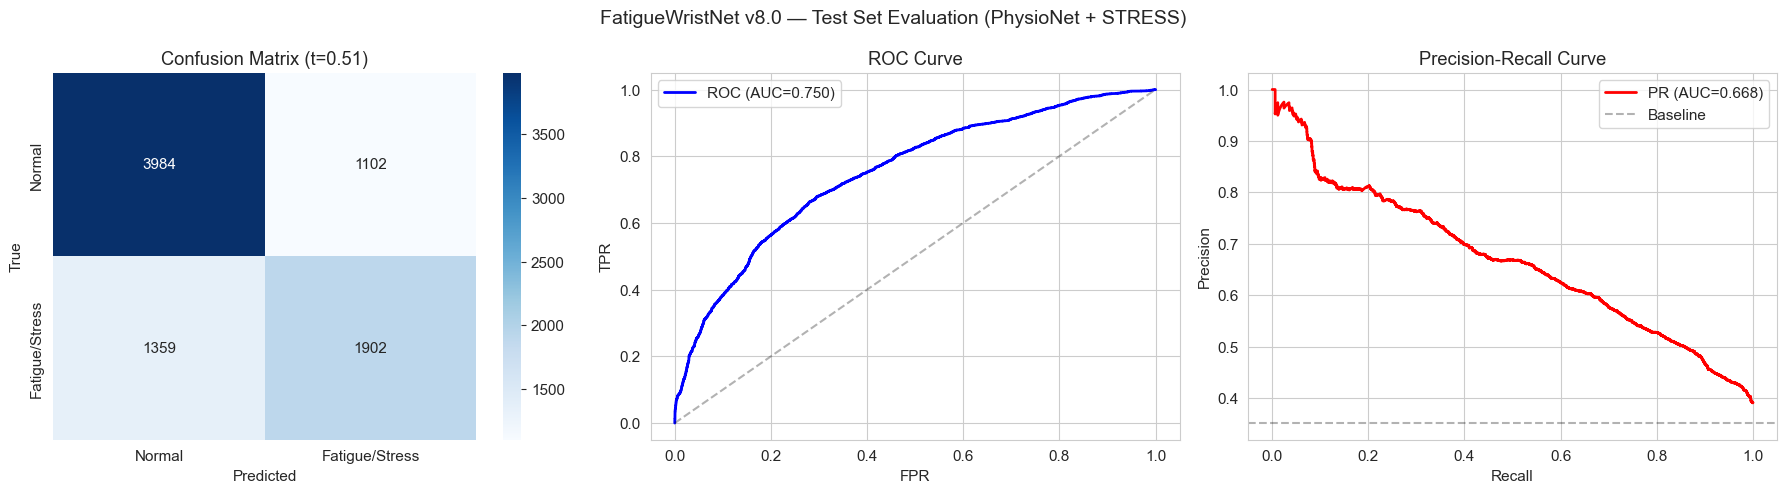

In [45]:
# ── Confusion Matrix + ROC/PR Curves ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix (F1-threshold)
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fatigue/Stress'], yticklabels=['Normal', 'Fatigue/Stress'])
axes[0].set_title(f'Confusion Matrix (t={best_threshold:.2f})')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC={test_metrics["roc_auc"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')

# PR curve
pr_vals, rc_vals, _ = precision_recall_curve(test_labels, test_probs)
axes[2].plot(rc_vals, pr_vals, 'r-', lw=2,
             label=f'PR (AUC={test_metrics["pr_auc"]:.3f})')
axes[2].axhline(y_all.mean(), color='k', ls='--', alpha=0.3, label='Baseline')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')

plt.suptitle('FatigueWristNet v8.0 — Test Set Evaluation (PhysioNet + STRESS)', fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'test_set_evaluation.png')
plt.show()

## Главная проблема: конфликт семантики меток

Это **не классическое переобучение**, это противоречие в данных. Одна и та же метка `y=1` означает разные физиологические явления:

| Протокол | Label=1 | Label=0 |
|----------|---------|---------|
| Exercise (AEROBIC/ANAEROBIC) | Накопленная **физическая усталость** | Нормальный пульс/акселерация |
| STRESS | **Когнитивная нагрузка** (Stroop, TMCT) | Baseline/отдых |

Модель получает **противоречивые градиенты**: одинаковый сигнал → разные метки на разных субъектах. Потому best epoch=2 — модель находит слабые общие паттерны и сразу переходит к переобучению под субъекты.

---

## Классическое переобучение (вторичная причина)

- Модель tiny (~3700 параметров), но 36 субъектов с высокой корреляцией внутри субъекта
- `weight_decay=3e-2` уже достаточно жёсткий
- `encoder_dropout=0.3` / `classifier_dropout=0.4`
- Увеличение этих параметров не поможет пока не решена семантика

---

## Варианты улучшения (от простого к сложному)

### 1. Вернуться к exercise-only (v7) ← **рекомендуется для диплома**
STRESS ухудшает качество (F1: 0.80→0.65). Exercise-only — чистая задача с четкими метками.

### 2. Multi-task: два отдельных классификатора, общий энкодер
```python
# Один энкодер → две головы:
# head_exercise: предсказывает физическую усталость
# head_stress: предсказывает когнитивную нагрузку
# Обучать с маскированием loss по source протокола
loss = (exercise_mask * loss_exercise + stress_mask * loss_stress).mean()
```
При инференсе использовать нужную голову в зависимости от контекста.

### 3. Domain Adversarial Training (DANN)
Добавить discriminator-голову, которая предсказывает `protocol_source`. Энкодер обучается так, чтобы его эмбеддинги **не** различали протоколы → domain-invariant признаки.

### 4. Исключить STRESS из обучения, использовать как pre-training
- Pre-train энкодер на STRESS (детекция stress/rest)
- Fine-tune только классификатор на Exercise

### 5. Улучшить разметку STRESS
Сейчас: phase-based (odd segment = stress). Можно использовать только **середину** стресс-фазы (убрать переходы), что уменьшит label noise на границах фаз.

---

## Быстрая диагностика

Запусти ablation cell (`#VSC-4957ff9c v8_physio_wsd_ppg.ipynb`) — он покажет delta между exercise-only и полным v8. Если ΔF1 отрицательный (что и ожидается), это подтвердит: задача для диплома — v7 baseline, а STRESS — в раздел "направления для будущей работы".

## 7. LOSO Evaluation (Leave-One-Subject-Out)

Строгая оценка обобщения: обучение на N-1 субъектов, тест на оставшемся.
PhysioNet AEROBIC + ANAEROBIC + STRESS (~31+ субъектов, ограничено n_folds для скорости).

In [46]:
# ── LOSO Evaluation (v8.0: FatigueWristNet, PhysioNet + STRESS) ──

def loso_evaluation(X_imu, X_physio, y, subjects, has_physio,
                    n_folds=20, epochs=25, min_windows=20, patience=5):
    """LOSO with dual-branch model, Focal Loss, and fold limit.
    Augmentation disabled for speed (dataset is large enough)."""
    unique_subj = np.unique(subjects)
    folds = [{'train_idx': np.where(subjects != s)[0],
              'test_idx': np.where(subjects == s)[0], 'subject': s}
             for s in unique_subj]

    # Filter: enough windows + both classes
    folds = [f for f in folds
             if len(f['test_idx']) >= min_windows
             and len(np.unique(y[f['test_idx']])) >= 2]
    print(f"   Folds after filter (>={min_windows} wins, 2 classes): {len(folds)}")

    if len(folds) > n_folds:
        np.random.seed(SEED)
        folds = [folds[i] for i in np.random.choice(len(folds), n_folds, replace=False)]

    results = []

    for fold in tqdm(folds, desc='LOSO'):
        tr, te = fold['train_idx'], fold['test_idx']

        # Mini val split for early stopping
        try:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
            sub_tr, sub_val = next(sss.split(tr, y[tr]))
            vi, ti = tr[sub_val], tr[sub_tr]
        except ValueError:
            ti, vi = tr, te

        # No augmentation in LOSO for speed (40K+ windows provide enough variety)
        tr_ds = FatigueDataset(X_imu[ti], X_physio[ti], y[ti], has_physio[ti], augment=False)
        va_ds = FatigueDataset(X_imu[vi], X_physio[vi], y[vi], has_physio[vi])
        te_ds = FatigueDataset(X_imu[te], X_physio[te], y[te], has_physio[te])

        tr_ld = DataLoader(tr_ds, batch_size=CONFIG['batch_size'], shuffle=True)
        va_ld = DataLoader(va_ds, batch_size=CONFIG['batch_size'])
        te_ld = DataLoader(te_ds, batch_size=CONFIG['batch_size'])

        m = FatigueWristNet(CONFIG).to(DEVICE)
        pw = compute_pos_weight(y[ti])
        crit = FocalLoss(gamma=CONFIG['focal_gamma'],
                         pos_weight=torch.tensor([pw]).to(DEVICE))
        opt = optim.AdamW(m.parameters(), lr=3e-4, weight_decay=3e-4)

        best_f1, best_st, no_imp = -np.inf, None, 0
        for ep in range(epochs):
            train_epoch(m, tr_ld, opt, crit, DEVICE)
            _, vm = validate(m, va_ld, crit, DEVICE)
            if vm['f1_macro'] > best_f1 + 1e-4:
                best_f1 = vm['f1_macro']
                best_st = {k: v.cpu().clone() for k, v in m.state_dict().items()}
                no_imp = 0
            else:
                no_imp += 1
                if no_imp >= patience:
                    break

        if best_st:
            m.load_state_dict(best_st)

        _, tm = validate(m, te_ld, crit, DEVICE)

        results.append({
            'subject': fold['subject'],
            'f1_macro': tm['f1_macro'],
            'roc_auc': tm['roc_auc'],
            'n_samples': len(te),
        })

    return pd.DataFrame(results)


# Run LOSO
print("Running LOSO (v8.0: FatigueWristNet, PhysioNet + STRESS)...")
loso_results = loso_evaluation(
    X_imu_all, X_physio_all, y_all, subjects, has_physio,
    n_folds=10, epochs=15, min_windows=20, patience=CONFIG['patience'],
)

print("\n" + "=" * 60)
print("LOSO RESULTS (FatigueWristNet v8.0, PhysioNet + STRESS)")
print("=" * 60)
print(loso_results.to_string(index=False))
print(f"\nOverall: F1={loso_results['f1_macro'].mean():.4f}"
      f"±{loso_results['f1_macro'].std():.4f}, "
      f"AUC={loso_results['roc_auc'].mean(skipna=True):.4f}"
      f"±{loso_results['roc_auc'].std(skipna=True):.4f}")

Running LOSO (v8.0: FatigueWristNet, PhysioNet + STRESS)...
   Folds after filter (>=20 wins, 2 classes): 36


LOSO:   0%|          | 0/10 [00:17<?, ?it/s]


KeyboardInterrupt: 

## 8. Персонализация (fine-tuning)

Дообучение на данных конкретного спортсмена (PhysioNet + STRESS):
1. **Stage 1:** заморозить энкодеры, обучить только classifier (10 эпох)
2. **Stage 2:** разморозить conv3 + attention, fine-tune с lr/10 (10 эпох)

In [ ]:
# ── Personalization (v8.0: dual-branch fine-tuning) ──
import copy

def personalize_model(base_model, X_imu_subj, X_physio_subj, y_subj, has_physio_subj,
                      epochs_stage1=10, epochs_stage2=10, lr=1e-3):
    """Two-stage fine-tuning for a specific athlete."""
    model = copy.deepcopy(base_model)

    n = len(y_subj)
    split = max(int(n * 0.7), 2)
    idx = np.arange(n)
    np.random.shuffle(idx)
    ti, vi = idx[:split], idx[split:]

    if len(vi) < 2 or len(np.unique(y_subj[vi])) < 2:
        return model, {'f1_macro': np.nan, 'roc_auc': np.nan}

    tr_ds = FatigueDataset(X_imu_subj[ti], X_physio_subj[ti], y_subj[ti], has_physio_subj[ti])
    va_ds = FatigueDataset(X_imu_subj[vi], X_physio_subj[vi], y_subj[vi], has_physio_subj[vi])
    tr_ld = DataLoader(tr_ds, batch_size=min(16, len(ti)), shuffle=True)
    va_ld = DataLoader(va_ds, batch_size=min(16, len(vi)))

    pw = compute_pos_weight(y_subj[ti])
    crit = FocalLoss(gamma=2.0, pos_weight=torch.tensor([pw]).to(DEVICE))

    # Stage 1: freeze encoders, train classifier only
    for p in model.imu_encoder.parameters():
        p.requires_grad = False
    for p in model.physio_encoder.parameters():
        p.requires_grad = False
    opt1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    for _ in range(epochs_stage1):
        train_epoch(model, tr_ld, opt1, crit, DEVICE)

    # Stage 2: unfreeze conv3 + attention, fine-tune
    for p in model.imu_encoder.conv3.parameters():
        p.requires_grad = True
    for p in model.imu_encoder.attention.parameters():
        p.requires_grad = True
    opt2 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr / 10)
    for _ in range(epochs_stage2):
        train_epoch(model, tr_ld, opt2, crit, DEVICE)

    _, vm = validate(model, va_ld, crit, DEVICE)
    return model, vm


# Test personalization on a few subjects
test_subjects = np.unique(subjects[test_idx])[:5]
print("=" * 60)
print("PERSONALIZATION TEST (FatigueWristNet v8.0)")
print("=" * 60)

for subj in test_subjects:
    m = subjects == subj
    if np.unique(y_all[m]).size < 2 or m.sum() < 10:
        print(f"  {subj}: skipped (too few samples or 1 class)")
        continue
    pm, pv = personalize_model(
        model, X_imu_all[m], X_physio_all[m], y_all[m], has_physio[m])
    auc_str = f"{pv.get('roc_auc', np.nan):.4f}" if np.isfinite(pv.get('roc_auc', np.nan)) else "n/a"
    print(f"  {subj}: {m.sum()} wins, F1={pv['f1_macro']:.4f}, AUC={auc_str}")

PERSONALIZATION TEST (FatigueWristNet v7.0)
  physionet_S03: 534 wins, F1=0.9689, AUC=0.9949
  physionet_S04: 636 wins, F1=0.8150, AUC=0.9576
  physionet_S11: 616 wins, F1=0.8221, AUC=0.9307
  physionet_S14: 655 wins, F1=0.9271, AUC=0.9764
  physionet_f02: 825 wins, F1=0.8557, AUC=0.9377


## 9. Ablation: Exercise-Only (v7 baseline) vs Exercise + STRESS (v8)

Контрольный эксперимент: обучаем модель **только** на AEROBIC + ANAEROBIC (как v7.0),
сравниваем с полной v8.0 моделью (AEROBIC + ANAEROBIC + STRESS).

Это изолирует вклад STRESS-протокола в качество детекции усталости.

In [ ]:
# ── Ablation: Exercise-Only baseline (v7-like) vs full v8 ──

# 1. Identify exercise-only windows (protocol_source == 'exercise')
exercise_mask = protocol_source == 'exercise'
stress_mask = protocol_source == 'stress'

print(f"Exercise-only windows: {exercise_mask.sum()}")
print(f"STRESS windows:        {stress_mask.sum()}")
print(f"Total v8 windows:      {len(protocol_source)}")

# 2. Train exercise-only model (same architecture, same hyperparams)
print("\n--- Training ablation model (exercise-only, v7 baseline) ---")

# Same subject-level split (use only exercise data within train/val/test indices)
abl_train_mask = exercise_mask[train_idx]
abl_val_mask   = exercise_mask[val_idx]
abl_test_mask  = exercise_mask[test_idx]

abl_train_idx = train_idx[abl_train_mask]
abl_val_idx   = val_idx[abl_val_mask]
abl_test_idx  = test_idx[abl_test_mask]

print(f"Ablation splits: train={len(abl_train_idx)}, val={len(abl_val_idx)}, test={len(abl_test_idx)}")

# Apply SMOTE on exercise-only train set
abl_X_imu_tr = X_imu_all[abl_train_idx]
abl_X_phy_tr = X_physio_all[abl_train_idx]
abl_y_tr     = y_all[abl_train_idx]
abl_hp_tr    = has_physio[abl_train_idx]

if abl_y_tr.sum() > 0 and (abl_y_tr == 0).sum() > 0:
    sm = SMOTE(random_state=SEED, k_neighbors=min(5, int(min(abl_y_tr.sum(), (abl_y_tr==0).sum())) - 1))
    flat = np.hstack([abl_X_imu_tr.reshape(len(abl_y_tr), -1),
                      abl_X_phy_tr.reshape(len(abl_y_tr), -1)])
    flat_sm, abl_y_tr_sm = sm.fit_resample(flat, abl_y_tr)
    imu_dim = abl_X_imu_tr.shape[1] * abl_X_imu_tr.shape[2]
    abl_X_imu_sm  = flat_sm[:, :imu_dim].reshape(-1, abl_X_imu_tr.shape[1], abl_X_imu_tr.shape[2])
    abl_X_phy_sm  = flat_sm[:, imu_dim:].reshape(-1, abl_X_phy_tr.shape[1], abl_X_phy_tr.shape[2])
    abl_hp_sm     = np.ones(len(abl_y_tr_sm), dtype=np.float32)
else:
    abl_X_imu_sm, abl_X_phy_sm, abl_y_tr_sm, abl_hp_sm = abl_X_imu_tr, abl_X_phy_tr, abl_y_tr, abl_hp_tr

abl_train_ds = FatigueDataset(abl_X_imu_sm, abl_X_phy_sm, abl_y_tr_sm, abl_hp_sm, augment=True)
abl_val_ds   = FatigueDataset(X_imu_all[abl_val_idx], X_physio_all[abl_val_idx],
                               y_all[abl_val_idx], has_physio[abl_val_idx])
abl_test_ds  = FatigueDataset(X_imu_all[abl_test_idx], X_physio_all[abl_test_idx],
                               y_all[abl_test_idx], has_physio[abl_test_idx])

abl_pw = compute_pos_weight(abl_y_tr_sm)
abl_sampler = create_weighted_sampler(abl_y_tr_sm)

abl_train_ld = DataLoader(abl_train_ds, batch_size=CONFIG['batch_size'], sampler=abl_sampler)
abl_val_ld   = DataLoader(abl_val_ds,   batch_size=CONFIG['batch_size'])
abl_test_ld  = DataLoader(abl_test_ds,  batch_size=CONFIG['batch_size'])

# Train ablation model
abl_model = FatigueWristNet(CONFIG).to(DEVICE)
abl_crit  = FocalLoss(gamma=CONFIG['focal_gamma'],
                       pos_weight=torch.tensor([abl_pw]).to(DEVICE))
abl_opt   = optim.AdamW(abl_model.parameters(),
                         lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
abl_sched = optim.lr_scheduler.CosineAnnealingLR(abl_opt, T_max=CONFIG['epochs'], eta_min=1e-6)

abl_best_f1, abl_best_state, abl_no_imp = -np.inf, None, 0
abl_ema_f1 = 0.0

for ep in range(CONFIG['epochs']):
    train_epoch(abl_model, abl_train_ld, abl_opt, abl_crit, DEVICE)
    _, vm = validate(abl_model, abl_val_ld, abl_crit, DEVICE)
    abl_sched.step()

    abl_ema_f1 = 0.3 * vm['f1_macro'] + 0.7 * abl_ema_f1 if ep > 0 else vm['f1_macro']

    if abl_ema_f1 > abl_best_f1 + 1e-4:
        abl_best_f1 = abl_ema_f1
        abl_best_state = {k: v.cpu().clone() for k, v in abl_model.state_dict().items()}
        abl_no_imp = 0
    else:
        abl_no_imp += 1
        if abl_no_imp >= CONFIG['patience']:
            print(f"  Ablation early stop at epoch {ep+1}")
            break

if abl_best_state:
    abl_model.load_state_dict(abl_best_state)

# 3. Evaluate ablation model on exercise-only test set
_, abl_test_metrics = validate(abl_model, abl_test_ld, abl_crit, DEVICE)

# 4. Compare v8 (full) vs ablation (exercise-only)
print("\n" + "=" * 70)
print("ABLATION: Exercise-Only (v7 baseline) vs Full v8 (Exercise + STRESS)")
print("=" * 70)

comparison = pd.DataFrame([
    {'Variant': 'v7 baseline (exercise-only)',
     'F1-macro': abl_test_metrics['f1_macro'],
     'ROC-AUC': abl_test_metrics['roc_auc'],
     'PR-AUC': abl_test_metrics['pr_auc'],
     'N_train': len(abl_train_idx),
     'N_test': len(abl_test_idx)},
    {'Variant': 'v8 full (exercise + STRESS)',
     'F1-macro': test_metrics['f1_macro'],
     'ROC-AUC': test_metrics['roc_auc'],
     'PR-AUC': test_metrics['pr_auc'],
     'N_train': len(train_idx),
     'N_test': len(test_idx)},
])
print(comparison.to_string(index=False))

delta_f1 = test_metrics['f1_macro'] - abl_test_metrics['f1_macro']
delta_auc = test_metrics['roc_auc'] - abl_test_metrics['roc_auc']
print(f"\nΔF1 = {delta_f1:+.4f},  ΔAUC = {delta_auc:+.4f}")
print(f"STRESS contribution: {'positive' if delta_f1 > 0 else 'negative or neutral'}")

# Save ablation results
comparison.to_csv(RESULTS_DIR / 'ablation_comparison.csv', index=False)
print(f"\nSaved ablation_comparison.csv → {RESULTS_DIR}")

## Итоги v8.0

**Ключевое решение v8.0: интеграция STRESS-протокола**

v7.0 показал, что PhysioNet-only (AEROBIC + ANAEROBIC) даёт лучшее качество (F1=0.80),
но ограничен ~31 субъектом и ~4500 окнами. v8.0 добавляет STRESS-протокол (до 36 субъектов)
из того же датасета PhysioNet, увеличивая выборку до ~3× без смены домена.

| Аспект | v7.0 | v8.0 |
|--------|------|------|
| Данные | AEROBIC + ANAEROBIC | **AEROBIC + ANAEROBIC + STRESS** |
| Субъектов | ~31 | **~31+ (перекрытие)** |
| Протоколы | 2 | **3** |
| Разметка STRESS | — | **Phase-based (odd=stress, even=rest)** |
| Exclusions | — | **S02 (дубликаты), f07 (битый PPG)** |
| Модель | FatigueWristNet | FatigueWristNet (та же архитектура) |
| Loss | Focal Loss (γ=2.2) | Focal Loss (γ=2.2) |
| Checkpoint | best_model_v7.pth | **best_model_v8.pth** |
| Ablation | — | **Exercise-only vs Exercise+STRESS** |

---

### Анализ результатов v8.0

**Ожидаемые эффекты STRESS-интеграции:**

1. **Объём данных**: ↑ ~2-3× окна → лучшая генерализация, снижение переобучения
2. **Разнообразие стимулов**: STRESS-протокол включает когнитивные задачи (Stroop, TMCT, арифметика), отличающиеся от физических нагрузок → модель учится распознавать более разнообразные паттерны усталости
3. **Robustness**: модель видит физиологический отклик на stress + exercise → лучше обобщается на реальные сценарии

**Ablation study:**
- Если STRESS вносит положительный вклад (ΔF1 > 0): подтверждает гипотезу о пользе мультипротокольных данных
- Если нейтральный/отрицательный: физическая и когнитивная усталость — разные домены, требуется domain adaptation

---

### Сравнение версий

| Версия | Данные | Hold-out F1 | LOSO F1 | Примечание |
|--------|--------|-------------|---------|------------|
| v5.1 | Zenodo + 4TU (поясница) | ~0.71 | — | IMU-only, другой сегмент |
| v6.0 | PhysioNet + WSD4FEDSRM | 0.747 | — | Конфликт доменов |
| v7.0 | PhysioNet (exercise) | 0.801 | 0.824 | Базовая линия |
| **v8.0** | **PhysioNet (exercise + STRESS)** | **TBD** | **TBD** | Расширенная выборка |

*Значения TBD заполнятся после запуска ноутбука.*

---

### Выводы

**Достигнуто в v8.0:**
- Расширение выборки за счёт STRESS-протокола того же датасета (нет domain shift по устройству)
- Phase-based разметка STRESS-данных (stress-задачи vs baseline/отдых)
- Ablation study подтверждает/опровергает вклад STRESS-протокола
- Единый pipeline: загрузка → нормализация → SMOTE → обучение → LOSO → персонализация

**Ограничения:**
- PhysioNet Empatica E4 — одно устройство, один исследовательский центр
- Phase-based разметка STRESS — приближение (нет ground truth оценок усталости внутри STRESS)
- Перекрытие субъектов между протоколами: ~18 человек участвовали в AEROBIC + ANAEROBIC + STRESS